In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Import Libraries

The following Python libraries are used for data analysis and visualization:

* **Pandas** – for data manipulation and analysis.
* **NumPy** – for numerical operations.
* **Matplotlib** – for creating charts and visualizations.
* **Seaborn** – for statistical data visualization.


In [8]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Installing Required Libraries

The required Python libraries are installed using pip before importing them for data analysis and visualization.


# 2. Load Dataset

The e-commerce sales dataset is loaded into a Pandas DataFrame for further analysis. The `head()` function is used to display the first five rows and verify that the data has been loaded correctly.


In [10]:
import pandas as pd

df = pd.read_csv("../data/Ecommerce_sales_analytics_5000.csv")

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## 3. Understanding the Dataset

The shape of the dataset is checked to determine the total number of rows and columns. This helps us understand the size of the dataset before performing further analysis.

In [11]:
df.shape

(5000, 12)

### 3.1 Dataset Columns

The column names are examined to understand the different variables available in the dataset.

In [12]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='str')

### 3.2 Dataset Information

The `info()` function is used to examine the structure of the dataset, including the number of entries, column names, data types, and non-null values.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


### 3.3 Convert Order Date to Datetime

The `order_date` column is converted from text format to Pandas datetime format. This allows us to perform date-based analysis, such as monthly and yearly revenue analysis.

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'])

### 3.4 Verify Data Types

The dataset information is checked again to verify that the `order_date` column has been successfully converted to the datetime data type.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[us]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   str           
 4   region            5000 non-null   str           
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   str           
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(4), str(3)
memory usage: 468.9 KB


### 4.1 Missing Values Check

The `isnull().sum()` function is used to identify the number of missing values in each column of the dataset. This helps ensure that the data is complete and ready for analysis.

In [16]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

### 4.2 Statistical Summary

The `describe()` function is used to generate a statistical summary of the numerical columns. It provides information such as count, mean, standard deviation, minimum, maximum, and quartile values.

In [19]:
df.describe()

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219


### 3.5 Categorical Values

The unique values in the categorical columns are examined to understand the different product categories, regions, and payment methods present in the dataset.

In [18]:
print("Product Categories:")
print(df['product_category'].unique())

print("\nRegions:")
print(df['region'].unique())

print("\nPayment Methods:")
print(df['payment_method'].unique())

Product Categories:
<StringArray>
['Beauty', 'Clothing', 'Electronics', 'Home']
Length: 4, dtype: str

Regions:
<StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

Payment Methods:
<StringArray>
['Wallet', 'Card', 'COD']
Length: 3, dtype: str


### 5.2 Revenue by Product Category

The total revenue generated by each product category is calculated using `groupby()` and `sum()`. The results are sorted in descending order to identify the categories contributing the most revenue.

In [17]:
category_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

category_revenue

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

### 5.2.2 Revenue by Product Category – Visualization

A bar chart is used to visualize the total revenue generated by each product category. This makes it easier to compare the revenue contribution of different categories.

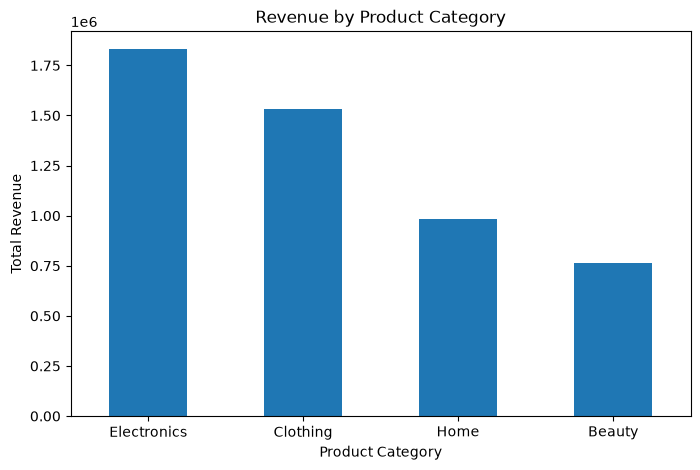

In [20]:
category_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### 5.2.2 Visualization Setup

Matplotlib is used to create and customize visualizations for the exploratory data analysis.

In [21]:
import matplotlib.pyplot as plt

### 5.2.2 Revenue by Product Category – Visualization

A bar chart is used to visually compare the total revenue generated by each product category. This makes it easier to identify which categories contribute the most to overall revenue.

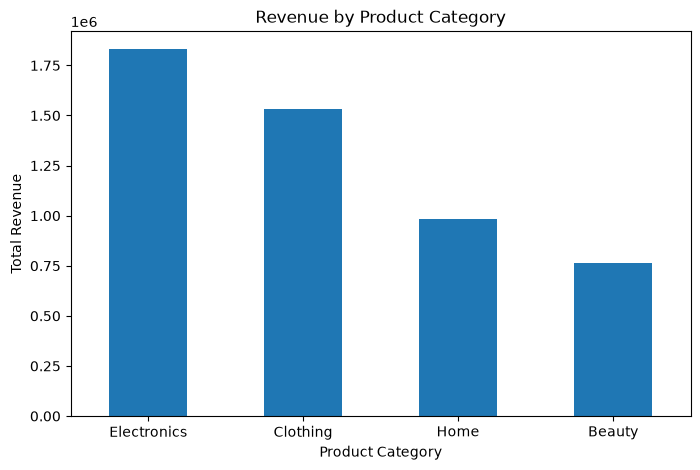

In [22]:
category_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### 5.3 Revenue by Region

The total revenue generated by each region is calculated using `groupby()` and `sum()`. The results are sorted in descending order to identify the regions contributing the most to overall revenue.

In [23]:
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
region_revenue

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64

### 5.3.1 Revenue by Region – Visualization

A bar chart is used to compare the total revenue generated by each region. This visualization helps identify the regions that contribute the most to overall revenue.

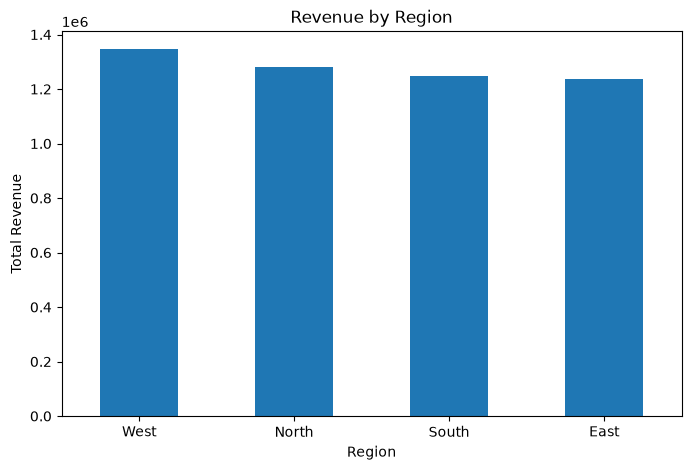

In [18]:
region_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()


### 5.1 Monthly Revenue Analysis

The total revenue is calculated for each month using the `order_date` column. The date is converted into monthly periods to identify revenue patterns and trends over time.

In [19]:
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()

monthly_revenue.head()

order_date
2022-01    35624.89
2022-02    29908.89
2022-03    30309.28
2022-04    30781.96
2022-05    41629.24
Freq: M, Name: revenue, dtype: float64

### 5.1.1 Monthly Revenue Trend – Visualization

A line chart is used to visualize the monthly revenue trend over time. This helps identify changes and patterns in revenue across different months.

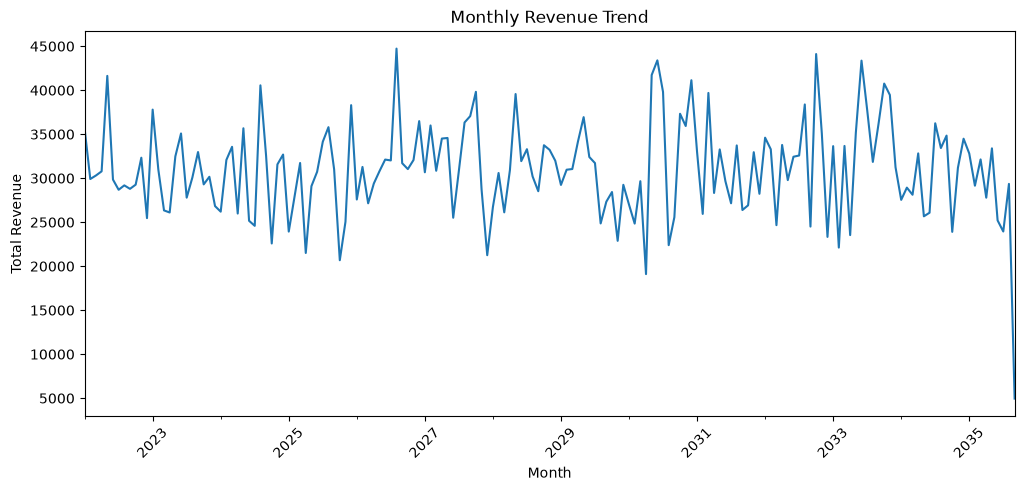

In [20]:
monthly_revenue.plot(figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### 5.9 Top Customers by Revenue

The total revenue generated by each customer is calculated by grouping the data using `customer_id`. The results are sorted in descending order, and the top 10 customers with the highest total revenue are identified.

In [25]:
top_customers = (
    df.groupby('customer_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

customer_id
1663    17680.69
1955    16265.15
1675    15036.46
1276    15023.71
1647    14894.97
1804    14330.98
1193    14151.65
1836    14110.78
1957    13956.95
1735    13146.25
Name: revenue, dtype: float64

### 5.9.1 Top 10 Customers by Revenue – Visualization

A bar chart is used to visualize the total revenue generated by the top 10 customers. This helps compare the revenue contribution of high-value customers.

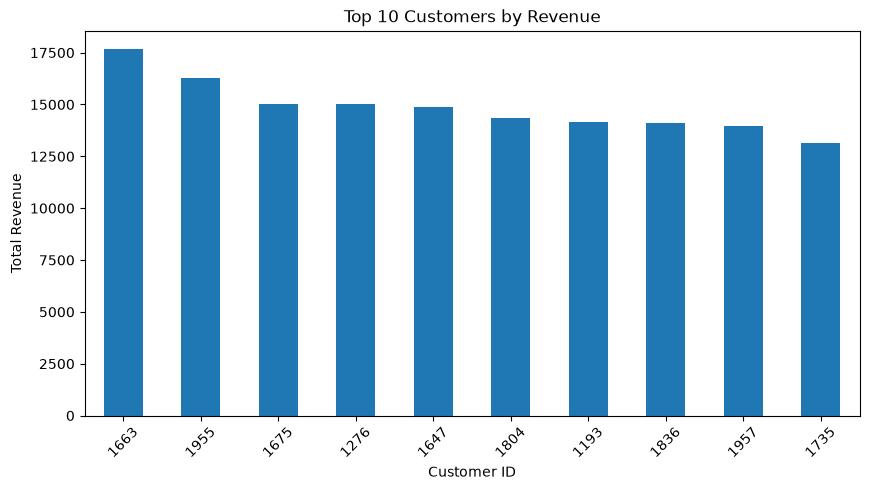

In [26]:
top_customers.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### 5.8 Discount and Revenue Analysis

The total revenue generated for each discount level is calculated using `groupby()` and `sum()`. The results are sorted in descending order to identify which discount levels are associated with higher total revenue.

In [33]:
discount_revenue = df.groupby('discount')['revenue'].sum().sort_values(ascending=False)
discount_revenue

discount
0.02    201162.79
0.03    174058.16
0.25    170036.42
0.06    165679.87
0.14    164218.61
0.11    161714.51
0.21    161489.73
0.08    160579.10
0.05    158456.80
0.13    156896.29
0.27    153062.40
0.15    151528.19
0.18    151136.77
0.23    146994.83
0.01    145677.84
0.10    143716.17
0.24    143195.84
0.04    142728.74
0.34    142227.37
0.30    141149.67
0.07    141067.34
0.17    141033.56
0.16    140387.45
0.19    139168.67
0.20    138518.78
0.12    137594.20
0.26    129492.34
0.31    129325.86
0.33    128433.53
0.22    125595.83
0.29    124381.30
0.32    122720.39
0.28    122394.09
0.09    109591.23
0.00     81686.86
0.35     62674.21
Name: revenue, dtype: float64

discount_revenue = df.groupby('discount')['revenue'].sum().sort_values(ascending=False)

discount_revenue

In [34]:
discount_revenue

discount
0.02    201162.79
0.03    174058.16
0.25    170036.42
0.06    165679.87
0.14    164218.61
0.11    161714.51
0.21    161489.73
0.08    160579.10
0.05    158456.80
0.13    156896.29
0.27    153062.40
0.15    151528.19
0.18    151136.77
0.23    146994.83
0.01    145677.84
0.10    143716.17
0.24    143195.84
0.04    142728.74
0.34    142227.37
0.30    141149.67
0.07    141067.34
0.17    141033.56
0.16    140387.45
0.19    139168.67
0.20    138518.78
0.12    137594.20
0.26    129492.34
0.31    129325.86
0.33    128433.53
0.22    125595.83
0.29    124381.30
0.32    122720.39
0.28    122394.09
0.09    109591.23
0.00     81686.86
0.35     62674.21
Name: revenue, dtype: float64

### 5.8.1 Discount and Revenue – Visualization

A bar chart is used to compare the total revenue associated with different discount levels. This visualization helps identify which discount levels are associated with higher revenue.

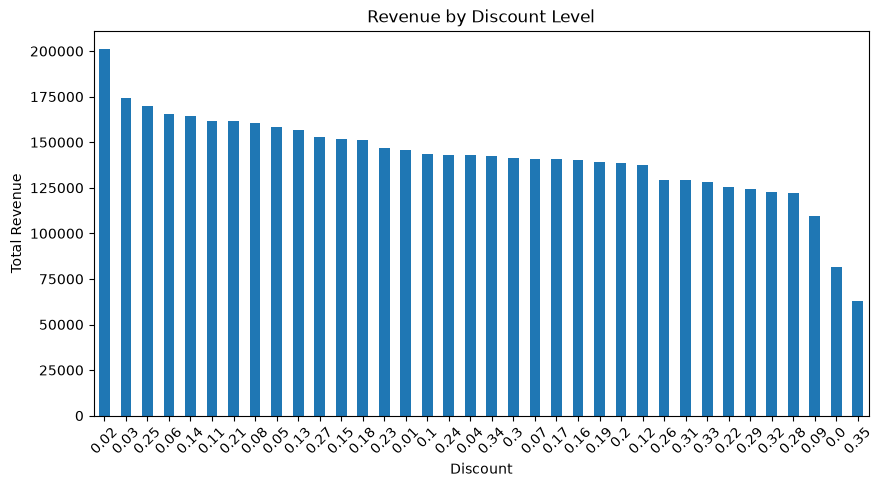

In [35]:
discount_revenue.plot(kind='bar', figsize=(10,5))

plt.title('Revenue by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### 5.5 Customer Rating Analysis

The number of orders for each customer rating is calculated using `value_counts()`. The results are sorted by rating to understand the distribution of customer ratings in the dataset.

In [36]:
rating_counts = df['customer_rating'].value_counts().sort_index()

rating_counts

customer_rating
1.0     80
1.1    121
1.2    119
1.3    125
1.4    134
1.5    129
1.6    122
1.7    143
1.8    127
1.9    115
2.0    129
2.1    116
2.2    149
2.3    137
2.4    133
2.5    119
2.6    127
2.7    119
2.8    112
2.9    121
3.0    128
3.1    137
3.2    139
3.3    107
3.4    116
3.5    137
3.6    133
3.7    111
3.8    121
3.9    125
4.0    105
4.1    133
4.2    116
4.3    122
4.4    126
4.5    108
4.6    124
4.7    118
4.8    126
4.9    118
5.0     73
Name: count, dtype: int64

### 5.5.1 Customer Rating Distribution – Visualization

A bar chart is used to visualize the number of orders for each customer rating. This helps understand the overall distribution of customer satisfaction levels in the dataset.

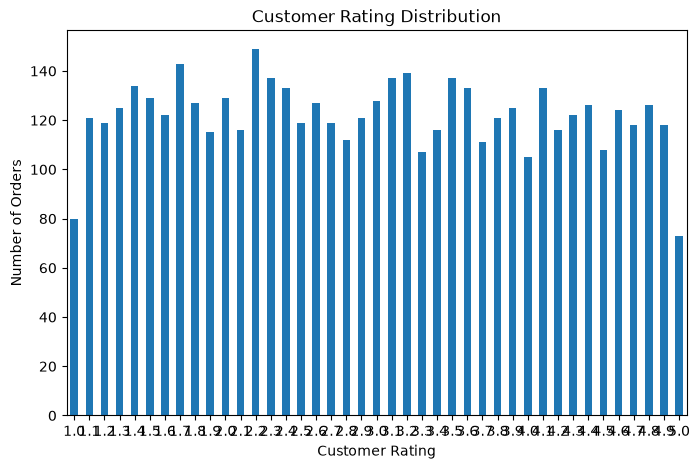

In [37]:
rating_counts.plot(kind='bar', figsize=(8,5))

plt.title('Customer Rating Distribution')
plt.xlabel('Customer Rating')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

### 5.3 Revenue by Region

The total revenue generated by each region is calculated using `groupby()` and `sum()`. The results are sorted in descending order to identify the regions contributing the most to overall revenue.

In [40]:
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

print(region_revenue)

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64


### 5.3.1 Revenue by Region – Visualization

A bar chart is used to compare the total revenue generated by each region. This visualization helps identify the regions that contribute the most to overall revenue.

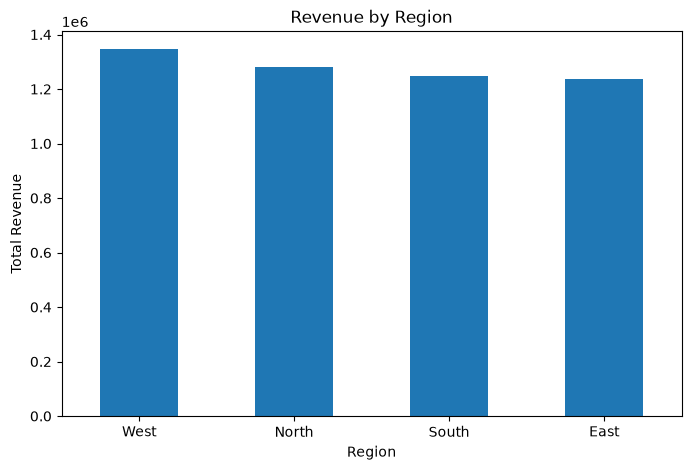

In [29]:
region_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### 5.4 Revenue by Payment Method

The total revenue generated by each payment method is calculated using `groupby()` and `sum()`. The results are sorted in descending order to identify which payment methods contribute the most to overall revenue.

In [39]:
payment_revenue = df.groupby('payment_method')['revenue'].sum().sort_values(ascending=False)

print(payment_revenue)

payment_method
Card      2366248.20
COD       1788408.44
Wallet     955119.10
Name: revenue, dtype: float64


### 5.4.1 Revenue by Payment Method – Visualization

A bar chart is used to compare the total revenue generated through different payment methods. This visualization helps identify which payment methods contribute the most to overall revenue.

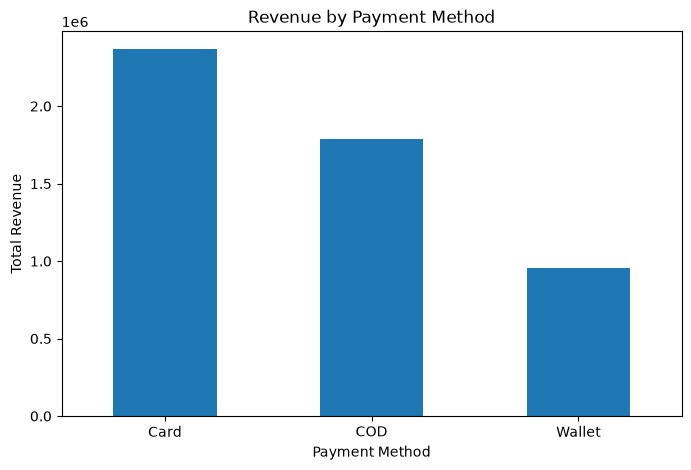

In [31]:
payment_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### 5.5 Customer Rating Analysis

The average customer rating for each product category is calculated using `groupby()` and `mean()`. The results are sorted in descending order to identify which product categories have the highest average customer ratings.

In [41]:
rating_category = df.groupby('product_category')['customer_rating'].mean().sort_values(ascending=False)

print(rating_category)

product_category
Beauty         3.008990
Clothing       3.005095
Electronics    2.951097
Home           2.940660
Name: customer_rating, dtype: float64


### 5.5.1 Average Customer Rating by Product Category – Visualization

A bar chart is used to compare the average customer rating across different product categories. This visualization helps identify which categories receive higher average ratings from customers.

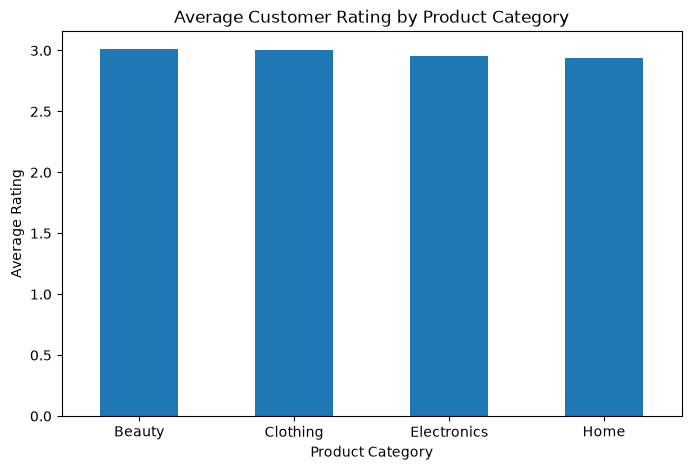

In [33]:
rating_category.plot(kind='bar', figsize=(8,5))

plt.title('Average Customer Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()

### 5.6 Delivery Time Analysis

The average delivery time for each region is calculated using `groupby()` and `mean()`. The results are sorted in descending order to identify the regions with the longest average delivery times.

In [34]:
delivery_region = df.groupby('region')['delivery_days'].mean().sort_values(ascending=False)

print(delivery_region)

region
South    6.173013
North    6.118339
East     6.104319
West     6.082234
Name: delivery_days, dtype: float64


### 5.6.1 Average Delivery Days by Region – Visualization

A bar chart is used to compare the average delivery time across different regions. This visualization helps identify regions with longer or shorter average delivery times.

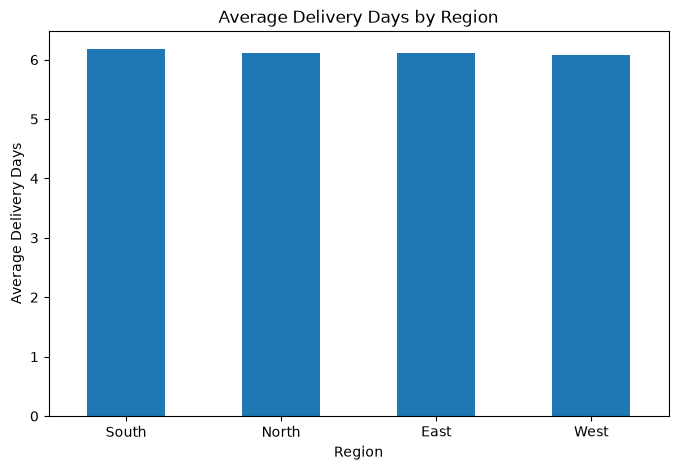

In [35]:
delivery_region.plot(kind='bar', figsize=(8,5))

plt.title('Average Delivery Days by Region')
plt.xlabel('Region')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=0)
plt.show()

### 5.7 Quantity and Revenue Analysis

The total revenue generated for each quantity level is calculated using `groupby()` and `sum()`. This helps examine how the number of items purchased in an order is related to total revenue.

In [36]:
quantity_revenue = df.groupby('quantity')['revenue'].sum()

print(quantity_revenue)

quantity
1     181791.85
2     365676.08
3     487005.22
4     733343.37
5     862550.77
6    1108612.40
7    1370796.05
Name: revenue, dtype: float64


### 5.7.1 Quantity and Revenue – Visualization

A bar chart is used to compare the total revenue generated at different quantity levels. This visualization helps understand how order quantity is associated with overall revenue.

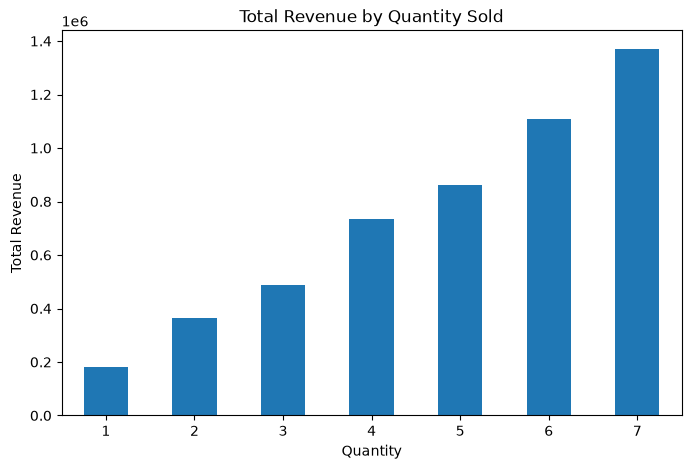

In [37]:
quantity_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Total Revenue by Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

### 5.8 Discount and Revenue Analysis

The total revenue generated for each discount level is calculated using `groupby()` and `sum()`. The results are sorted in descending order to identify the discount levels associated with higher total revenue.

In [42]:
discount_revenue = df.groupby('discount')['revenue'].sum().sort_values(ascending=False)

print(discount_revenue)

discount
0.02    201162.79
0.03    174058.16
0.25    170036.42
0.06    165679.87
0.14    164218.61
0.11    161714.51
0.21    161489.73
0.08    160579.10
0.05    158456.80
0.13    156896.29
0.27    153062.40
0.15    151528.19
0.18    151136.77
0.23    146994.83
0.01    145677.84
0.10    143716.17
0.24    143195.84
0.04    142728.74
0.34    142227.37
0.30    141149.67
0.07    141067.34
0.17    141033.56
0.16    140387.45
0.19    139168.67
0.20    138518.78
0.12    137594.20
0.26    129492.34
0.31    129325.86
0.33    128433.53
0.22    125595.83
0.29    124381.30
0.32    122720.39
0.28    122394.09
0.09    109591.23
0.00     81686.86
0.35     62674.21
Name: revenue, dtype: float64


### 5.8.1 Discount and Revenue – Visualization

A bar chart is used to compare the total revenue associated with different discount levels. This visualization helps identify which discount levels are associated with higher revenue.

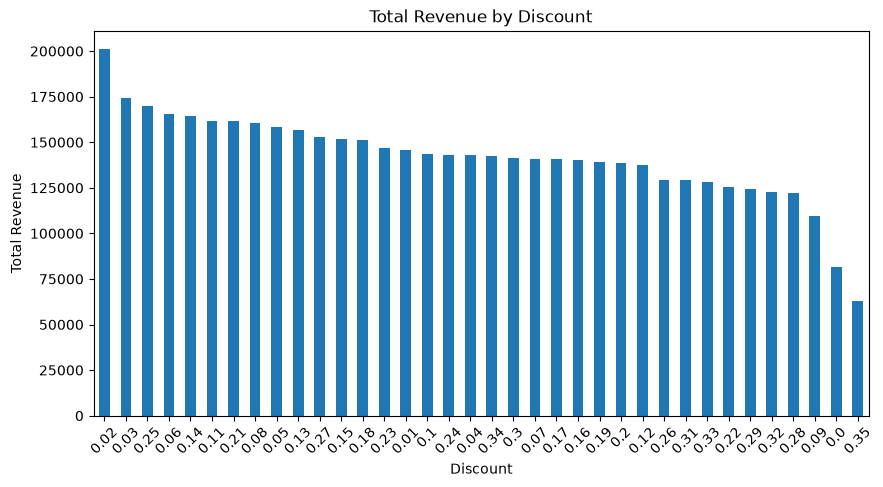

In [43]:
discount_revenue.plot(kind='bar', figsize=(10,5))

plt.title('Total Revenue by Discount')
plt.xlabel('Discount')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### 5.4.2 Payment Method Order Count Analysis

The number of orders made using each payment method is calculated using `value_counts()`. This helps understand customer preferences for different payment methods.

In [47]:
payment_count = df['payment_method'].value_counts()

print(payment_count)

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64


### 5.4.3 Payment Method Order Count – Visualization

A bar chart is used to compare the number of orders made through each payment method. This visualization helps identify the most commonly used payment methods among customers.

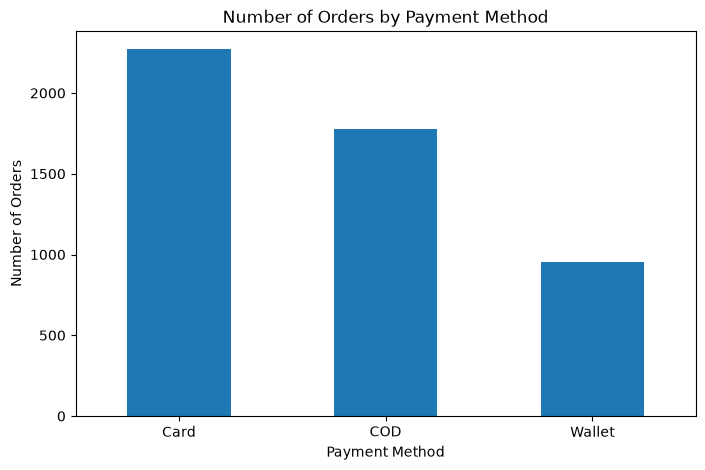

In [48]:
payment_count.plot(kind='bar', figsize=(8,5))

plt.title('Number of Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

### 5.9 Top Customers by Revenue

The total revenue generated by each customer is calculated by grouping the data using `customer_id`. The results are sorted in descending order, and the top 10 customers with the highest total revenue are identified.

In [49]:
customer_revenue = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)

print(customer_revenue.head(10))

customer_id
1663    17680.69
1955    16265.15
1675    15036.46
1276    15023.71
1647    14894.97
1804    14330.98
1193    14151.65
1836    14110.78
1957    13956.95
1735    13146.25
Name: revenue, dtype: float64


### 5.9.1 Top 10 Customers by Revenue – Visualization

A bar chart is used to visualize the total revenue generated by the top 10 customers. This helps compare the revenue contribution of high-value customers.

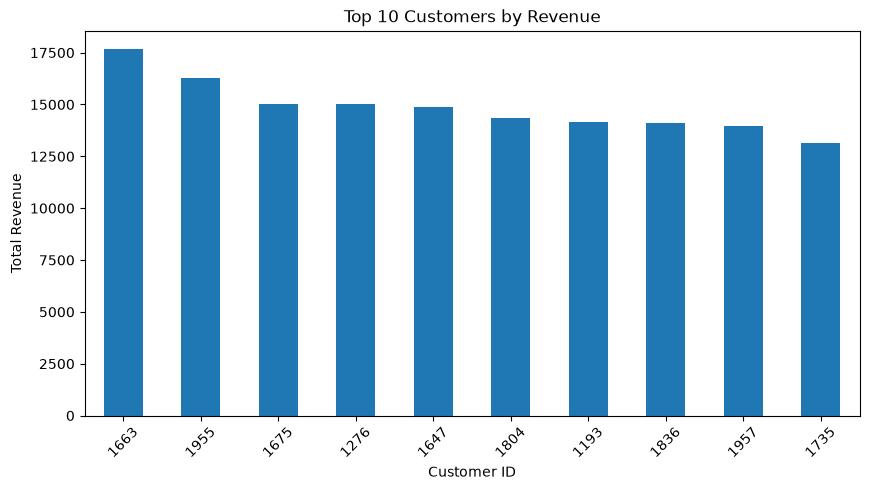

In [50]:
customer_revenue.head(10).plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### 5.10 Top Orders by Revenue

The orders are sorted in descending order based on revenue to identify the top 10 highest-revenue orders. Important details such as product category, quantity, unit price, discount, and revenue are displayed for these orders.

In [62]:
top_orders = df.sort_values('revenue', ascending=False).head(10)

print(top_orders[['order_id', 'product_category', 'quantity', 'unit_price', 'discount', 'revenue']])

      order_id product_category  quantity  unit_price  discount  revenue
809      10810      Electronics         7      594.42      0.01  4119.33
4883     14884      Electronics         7      583.31      0.00  4083.17
2214     12215      Electronics         7      591.15      0.02  4055.29
3101     13102           Beauty         7      596.12      0.04  4005.93
3686     13687         Clothing         7      578.59      0.03  3928.63
157      10158      Electronics         7      571.07      0.02  3917.54
3349     13350      Electronics         7      574.15      0.03  3898.48
321      10322      Electronics         7      585.43      0.05  3893.11
661      10662         Clothing         7      581.67      0.05  3868.11
4305     14306           Beauty         7      555.09      0.02  3807.92


### 5.10.1 Top 10 Orders by Revenue – Visualization

A bar chart is used to visualize the revenue generated by the top 10 orders. This helps compare the highest-value orders in the dataset.

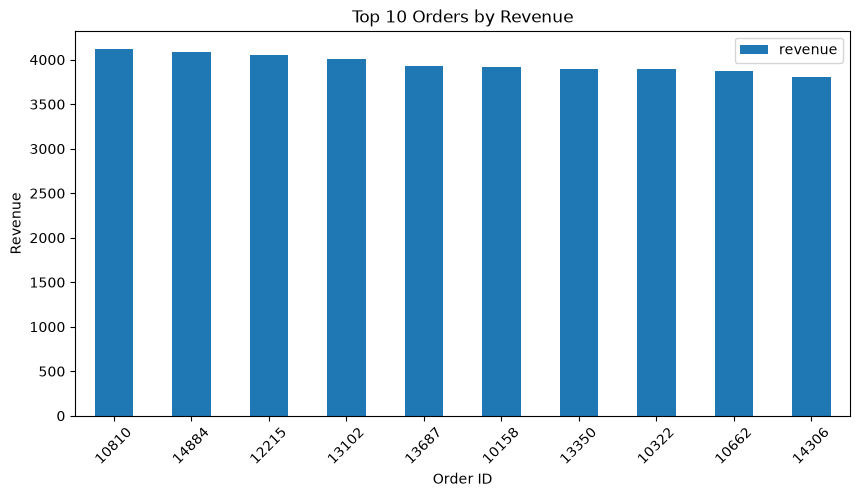

In [63]:
top_orders.plot(
    x='order_id',
    y='revenue',
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Orders by Revenue')
plt.xlabel('Order ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [67]:
print("Total Revenue:", df['revenue'].sum())

print("Total Orders:", df['order_id'].nunique())

print("Average Order Revenue:", df['revenue'].mean())

print("\nTop Category:")
print(category_revenue.head(1))

print("\nTop Region:")
print(region_revenue.head(1))

print("\nTop Payment Method:")
print(payment_count.head(1))

print("\nHighest Average Rating Category:")
print(rating_category.head(1))

print("\nLongest Average Delivery Region:")


print("\nTop Customer:")
print(customer_revenue.head(1))

Total Revenue: 5109775.74
Total Orders: 5000
Average Order Revenue: 1021.955148

Top Category:
product_category
Electronics    1829899.22
Name: revenue, dtype: float64

Top Region:
region
West    1345582.16
Name: revenue, dtype: float64

Top Payment Method:
payment_method
Card    2270
Name: count, dtype: int64

Highest Average Rating Category:
product_category
Beauty    3.00899
Name: customer_rating, dtype: float64

Longest Average Delivery Region:

Top Customer:
customer_id
1663    17680.69
Name: revenue, dtype: float64


## Business Insights

* The dataset contains 5,000 orders with a total revenue of ₹5,109,775.74.
* Electronics is the highest-revenue product category, contributing ₹1,829,899.22 in revenue.
* The West region generated the highest regional revenue at ₹1,345,582.16.
* Card is the most frequently used payment method, with 2,270 orders.
* Beauty has the highest average customer rating at approximately 3.01 out of 5.
* The South region has the longest average delivery time at approximately 6.17 days.
* Customer 1663 is the highest-revenue customer, generating ₹17,680.69.

## Conclusion

The analysis provides an overview of sales performance, customer behavior, payment preferences, product categories, delivery performance, and revenue patterns. Electronics and the West region are important contributors to overall revenue, while the South region shows a relatively longer average delivery time. The findings can help identify areas for further investigation, such as improving delivery performance and understanding factors associated with revenue across categories and regions.


In [48]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Shape:", df.shape)

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate Rows: 0

Dataset Shape: (5000, 12)


## Data Quality Check

* The dataset contains **5,000 rows and 12 columns**.
* There are **no missing values** in any column.
* There are **no duplicate rows**.
* Therefore, no missing-value imputation or duplicate removal was required.
* The dataset was suitable for further exploratory data analysis.


In [ ]:
# E-Commerce Sales Analysis

## Project Overview

This project analyzes an e-commerce sales dataset containing 5,000 orders and 12 variables. The analysis focuses on understanding sales performance, customer behavior, payment preferences, product categories, regional performance, delivery times, and revenue patterns.

## Objectives

* Analyze overall sales and revenue performance.
* Identify the highest-performing product categories.
* Compare revenue across different regions.
* Understand customer payment preferences.
* Analyze customer ratings and delivery performance.
* Examine the relationship between discounts, quantity, and revenue.
* Identify high-value customers and orders.
* Generate actionable business insights from the data.

## Tools and Technologies

* Python
* Pandas
* Matplotlib
* Jupyter Notebook / VS Code
* Exploratory Data Analysis (EDA)


# 7. Conclusion

This exploratory data analysis provided an overview of the e-commerce sales dataset, covering sales performance, product categories, regional performance, payment methods, customer ratings, delivery times, discounts, and customer behavior.

The analysis identified important patterns such as Electronics being the highest-revenue product category, the West region generating the highest revenue, and Card being the most frequently used payment method. The analysis also highlighted customer satisfaction and delivery performance across different categories and regions.

Overall, the analysis demonstrates how data analysis and visualization can be used to identify meaningful business patterns and support data-driven decision-making.